In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    final_result: int


In [3]:
def adder_node(state: AgentState) -> AgentState:
    """This node adds two numbers and returns the result."""
    state["final_result"] = state["number1"] + state["number2"]
    return state

In [4]:
def substractor_node(state: AgentState) -> AgentState:
    """This node substract two numbers and returns the result."""
    state["final_result"] = state["number1"] - state["number2"]
    return state

In [5]:
def decider_node(state: AgentState) -> str:
    """This node decides which operation to perform based on the 'operation' key in the state."""
    if state["operation"] == "+":
        return "add"
    elif state["operation"] == "-":
        return "subtract"
    else:
        raise ValueError("Invalid operation. Use '+' or '-'.")

In [6]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder_node)
graph.add_node("substractor", substractor_node)
graph.add_node("decider", lambda state:state)

graph.add_edge(START, "decider")
graph.add_conditional_edges(
    "decider", 
    decider_node,
    {   #Edge : Node that we use creating the graph
        "add": "adder",
        "subtract": "substractor"
    }
)
graph.add_edge("adder", END)
graph.add_edge("substractor", END)

app =graph.compile()

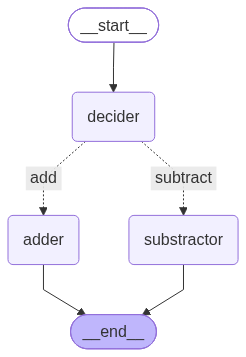

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
initial_state = AgentState(number1=10, number2=5, operation="+")
print(app.invoke(initial_state))  

{'number1': 10, 'number2': 5, 'operation': '+', 'final_result': 15}
